<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab8/Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 8**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## **Pregunta 1**

(a) Genera un proceso ruido blanco, $\epsilon_t\sim N(0,1)$.

In [51]:
# Generación del Proceso de Ruido Blanco
np.random.seed(42)
n_obs = 250
# ruido_blanco = np.random.normal(loc=0, scale=1, size=n_obs)
ruido_blanco = np.random.uniform(low= -1 , high= 1, size=n_obs)

# Crear Serie con índice numérico por defecto (0 a 499)
df_rb = pd.Series(ruido_blanco, name="Ruido_Blanco")

(b) Grafica la serie del ruido blanco, la función de autocorrelación y autocorrelación parcial.

/tmp/ipykernel_1521/2044506309.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper right")


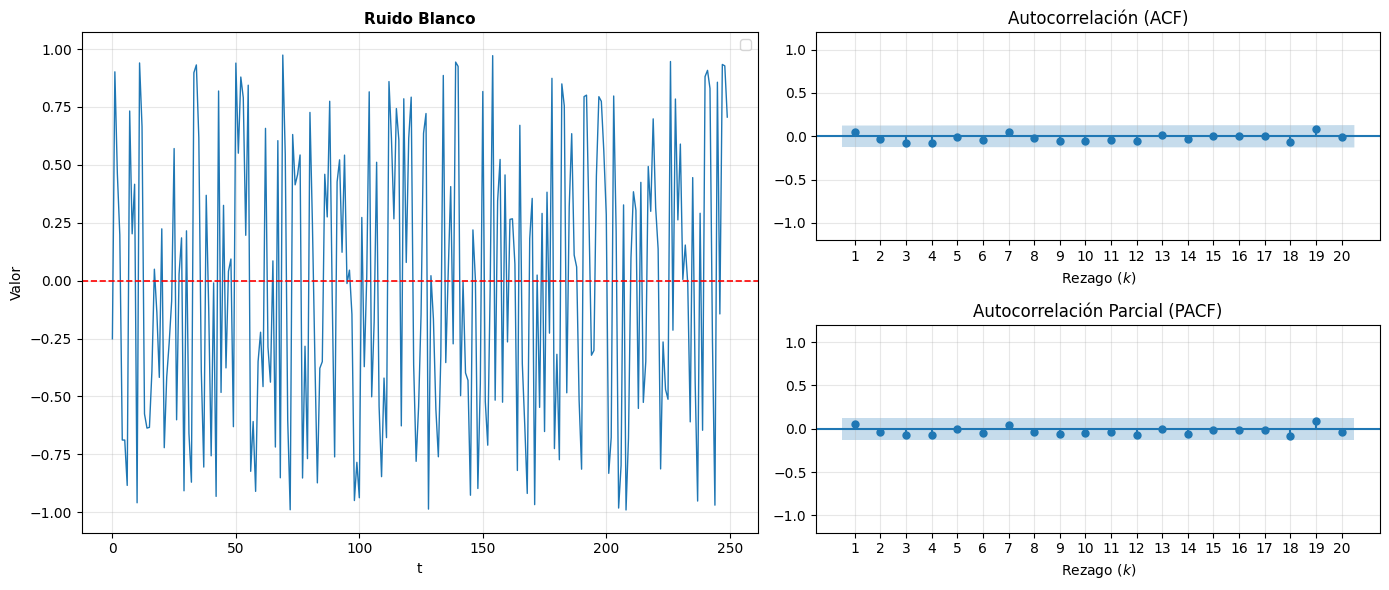

In [52]:
# Gráficos
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

lags_mostrar = 20

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(df_rb.index, df_rb.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Ruido Blanco", fontsize=11, fontweight="bold")
ax1.set_xlabel("t")  # En lugar de "Fecha"
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(df_rb, ax=ax2, lags=20, zero=False,  title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)


# COLUMNA 2 (inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(df_rb, ax=ax3, lags=20, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie de ruido blanco es estacionaria. Usa un nivel de significancia de 5%

In [53]:
# Aplicar el test Dickey-Fuller Aumentado
resultado_adf = adfuller(df_rb)

print('Resultados del Test Dickey-Fuller Aumentado:')
print(f'Estadístico ADF: {resultado_adf[0]:.4f}')
print(f'Valor p: {resultado_adf[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado:
Estadístico ADF: -14.8909
Valor p: 0.0000
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/3033814786.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(df_rb)


## **Pregunta 2**

(a) Simula el siguiente proceso AR(1):

$$y_t=0.8y_{t-1}+\epsilon_t$$

In [82]:
# 1. Simulación del proceso AR(1):
# np.random.seed(1042)
n_obs = 250
e = np.random.normal(loc=0, scale=1, size=n_obs)
y = np.zeros(n_obs)

# Construcción recursiva de la serie
y[0] = e[0]
for t in range(1, n_obs):
    y[t] = 0.8*y[t - 1] + e[t]

# Crear Serie con índice numérico secuencial (sin fechas)
serie_ar1 = pd.Series(y, name="AR1_Estacionario")


(b) Grafica la serie del AR(1), la función de autocorrelación y autocorrelación parcial.

/tmp/ipykernel_1521/2383739455.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper right")


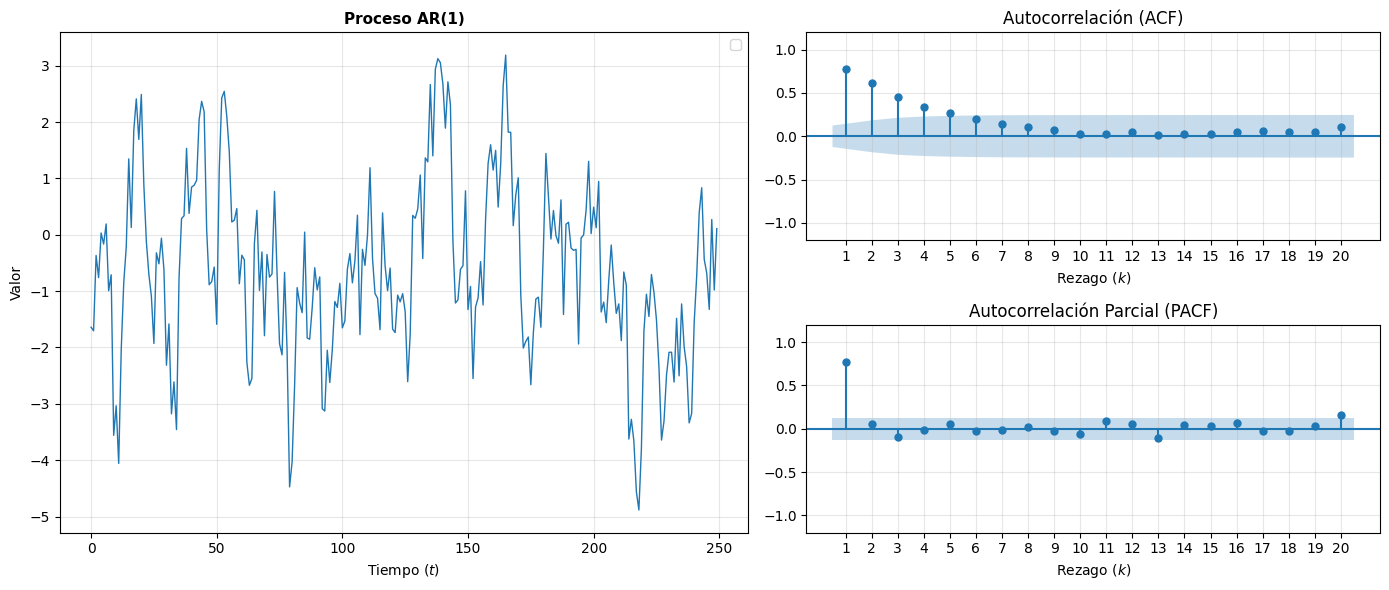

In [83]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_ar1.index, serie_ar1.values, color="#1f77b4", linewidth=1)
# ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(
    r"Proceso AR(1)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_ar1, ax=ax2, lags=20, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_ar1, ax=ax3, lags=20, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie AR(1) es estacionaria. Usa un nivel de significancia de 5%

In [84]:
resultado_adf_ar1 = adfuller(serie_ar1)

print('Resultados del Test Dickey-Fuller Aumentado para la serie AR(1):')
print(f'Estadístico ADF: {resultado_adf_ar1[0]:.4f}')
print(f'Valor p: {resultado_adf_ar1[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_ar1[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_ar1[1] <= 0.05:
    print('La serie AR(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie AR(1) no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie AR(1):
Estadístico ADF: -5.6033
Valor p: 0.0000
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie AR(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/224776757.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_ar1 = adfuller(serie_ar1)


(d) Repite las preguntas (a), (b) y (c) para los siguientes procesos:

(i) $y_t=0.5 + 0.8y_{t-1}+\epsilon_t$

(ii) $y_t=1.03y_{t-1}+\epsilon_t$

(iii) $y_t=y_{t-1}+\epsilon_t$

(iv) $y_t=0.05+y_{t-1}+\epsilon_t$


## **Pregunta 3**

(a) Simula el siguiente proceso MA(1):

$$y_t=\epsilon_t+0.5\epsilon_{t-1}$$
donde $\epsilon_t \sim N(0,1)$.

In [93]:
# 1. Simulación del proceso MA(1): y_t = epsilon_t + 0.5*epsilon_{t-1}
n_obs = 250
np.random.seed(42) # Para reproducibilidad
epsilon = np.random.normal(loc=0, scale=1, size=n_obs)

y_ma1 = np.zeros(n_obs)

# Construcción de la serie MA(1)
# El primer término y[0] solo depende de epsilon[0] (asumiendo epsilon[-1]=0)
y_ma1[0] = epsilon[0]
for t in range(1, n_obs):
    y_ma1[t] = epsilon[t] + 0.6 * epsilon[t-1]

# Crear Serie con índice numérico secuencial
serie_ma1 = pd.Series(y_ma1, name="MA1_Estacionario")

(b) Grafica la serie del MA(1), la función de autocorrelación y autocorrelación parcial.

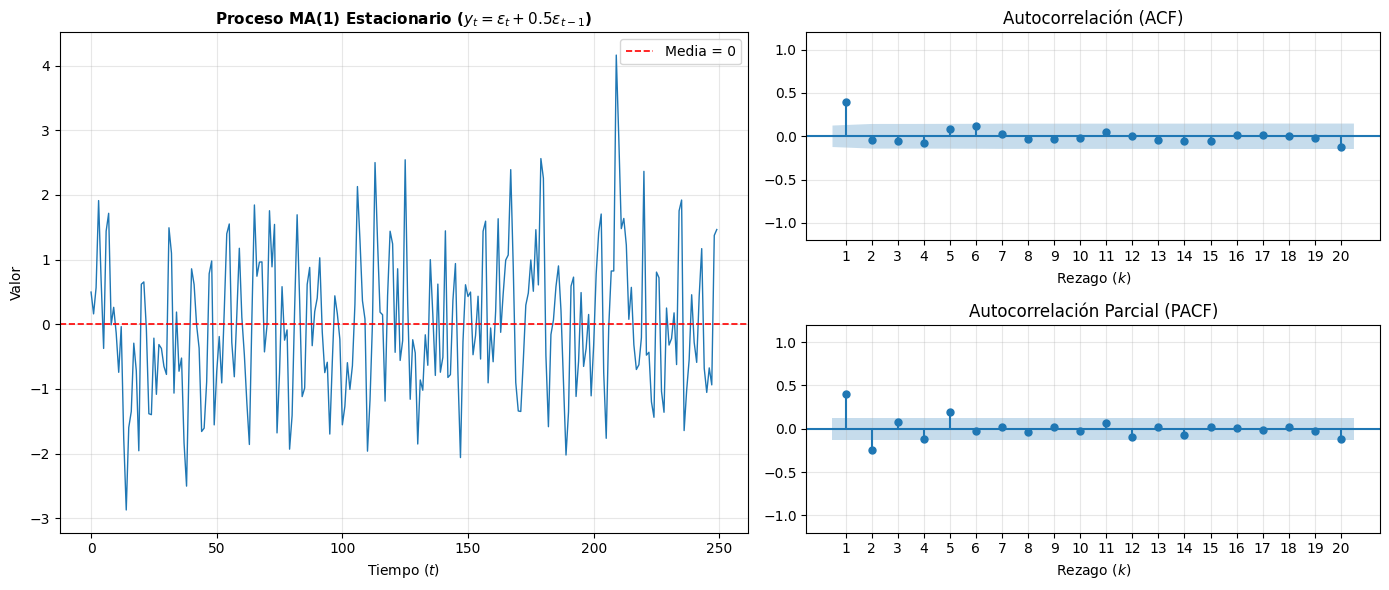

In [94]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_ma1.index, serie_ma1.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2, label="Media = 0")
ax1.set_title(
    r"Proceso MA(1)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_ma1, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_ma1, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie MA(1) es estacionaria. Usa un nivel de significancia de 5%

In [95]:
resultado_adf_ma1 = adfuller(serie_ma1)

print('Resultados del Test Dickey-Fuller Aumentado para la serie MA(1):')
print(f'Estadístico ADF: {resultado_adf_ma1[0]:.4f}')
print(f'Valor p: {resultado_adf_ma1[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_ma1[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_ma1[1] <= 0.05:
    print('La serie MA(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie MA(1) no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie MA(1):
Estadístico ADF: -5.9531
Valor p: 0.0000
Valores críticos:
   1%: -3.4573
   5%: -2.8734
   10%: -2.5731
La serie MA(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/1642878321.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_ma1 = adfuller(serie_ma1)


## **Pregunta 4**

(a) Simula un proceso con una tendencia determinista:

$$y_t = 5 + 0.2t + \epsilon_t$$
donde $\epsilon_t \sim N(0,1)$.

In [99]:
# 1. Simulación de un proceso con tendencia determinista: y_t = 5 + 0.2*t + epsilon_t
n_obs = 250
np.random.seed(42) # Para reproducibilidad
epsilon = np.random.normal(loc=0, scale=1, size=n_obs)

t = np.arange(n_obs) # Generar los valores de tiempo t
y_trend = 5 + 0.2 * t + epsilon

# Crear Serie con índice numérico secuencial
serie_trend = pd.Series(y_trend, name="Serie_con_Tendencia")

(b) Grafica la serie con tendencia determinista, la función de autocorrelación y autocorrelación parcial.

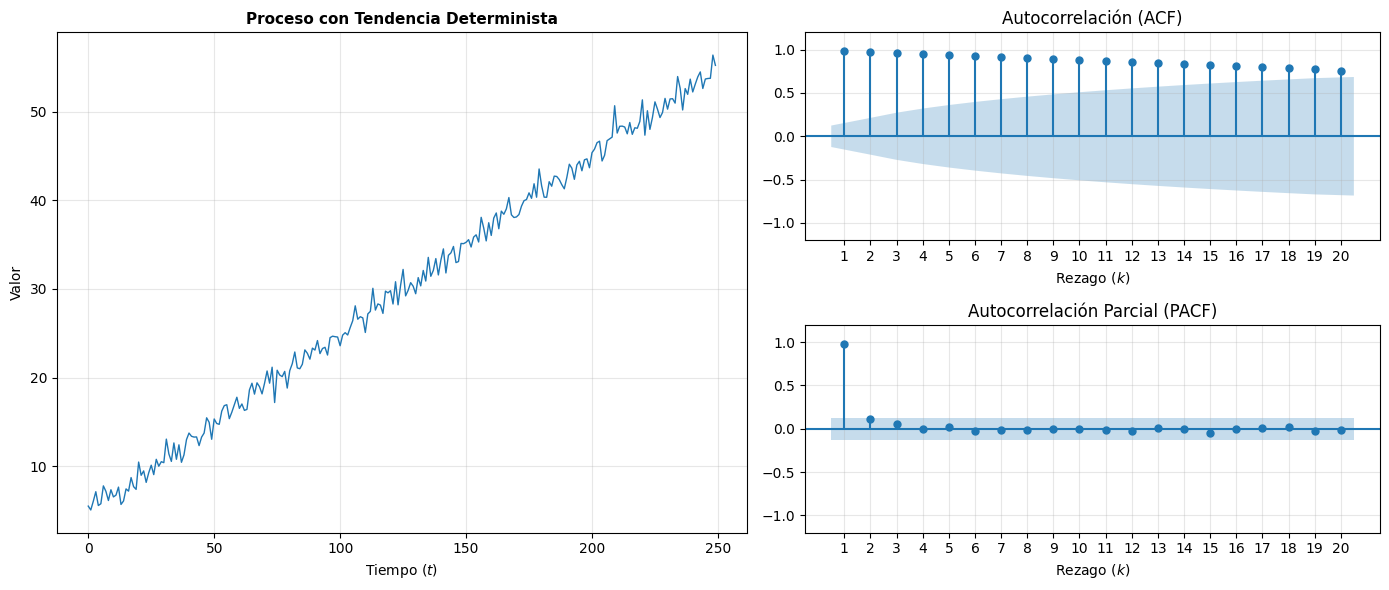

In [100]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_trend.index, serie_trend.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Proceso con Tendencia Determinista",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_trend, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_trend, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie con tendencia determinista es estacionaria. Usa un nivel de significancia de 5%

In [101]:
resultado_adf_trend = adfuller(serie_trend)

print('Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista:')
print(f'Estadístico ADF: {resultado_adf_trend[0]:.4f}')
print(f'Valor p: {resultado_adf_trend[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_trend[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_trend[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista:
Estadístico ADF: 0.2454
Valor p: 0.9747
Valores críticos:
   1%: -3.4580
   5%: -2.8737
   10%: -2.5733
La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/1461605589.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_trend = adfuller(serie_trend)


(d) Aplica primeras diferencias para remover tendencia ¿Es la serie resultante estacionaria?

--- Haciendo estacionaria la serie con Tendencia Determinista ---

Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista (diferenciada):
Estadístico ADF: -8.5950
Valor p: 0.0000
Valores críticos:
   1%: -3.4580
   5%: -2.8737
   10%: -2.5733
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/3144805973.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_trend_diff = adfuller(serie_trend_diff)


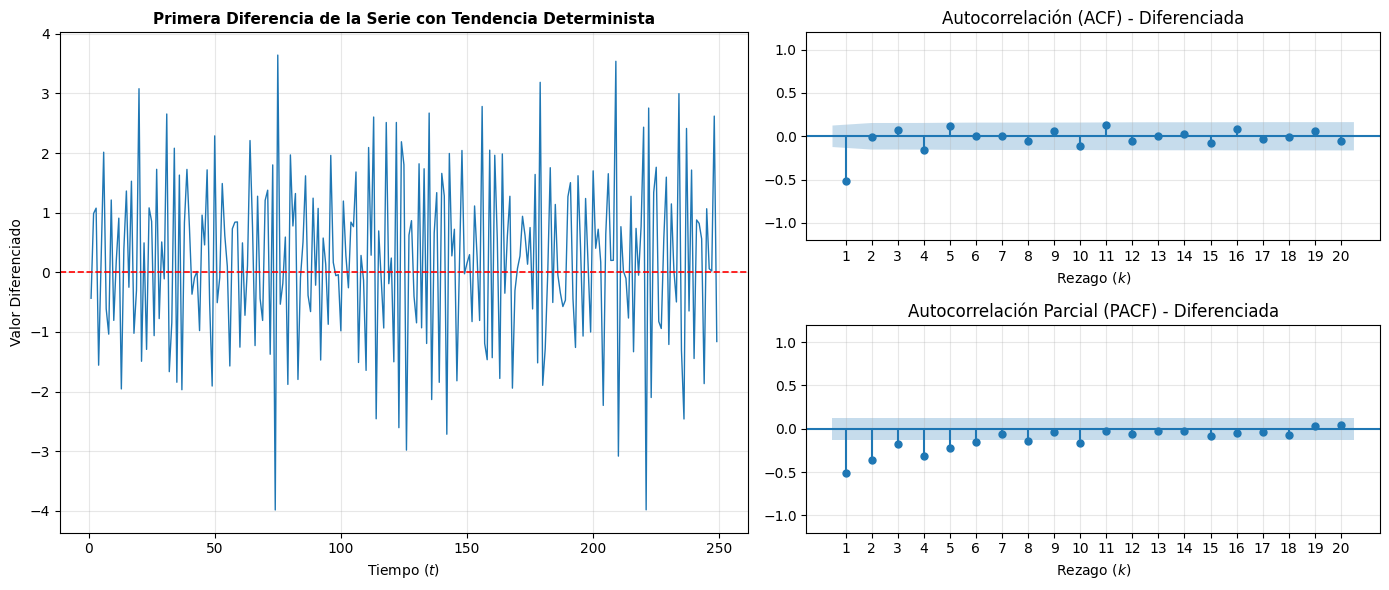

In [102]:
# Aplicar la primera diferencia para remover la tendencia
serie_trend_diff = serie_trend.diff().dropna()

# Realizar el test ADF a la serie diferenciada
resultado_adf_trend_diff = adfuller(serie_trend_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista (diferenciada):')
print(f'Estadístico ADF: {resultado_adf_trend_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_trend_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_trend_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_trend_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_trend_diff.index, serie_trend_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera Diferencia de la Serie con Tendencia Determinista", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor Diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_trend_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_trend_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Pregunta 5**

(a) Simula un proceso de **camino aleatorio** (random walk):

$$y_t = y_{t-1} + \epsilon_t$$

donde $\epsilon_t \sim N(0,1)$ y $y_0 = 0$.

In [109]:
# 1. Simulación de un proceso de camino aleatorio: y_t = y_{t-1} + epsilon_t
n_obs = 250
# np.random.seed(3456) # Para reproducibilidad
epsilon_rw = np.random.normal(loc=0, scale=1, size=n_obs)

y_rw = np.zeros(n_obs)
y_rw[0] = 0 # y_0 = 0

for t in range(1, n_obs):
    y_rw[t] = y_rw[t-1] + epsilon_rw[t]

# Crear Serie con índice numérico secuencial
serie_rw = pd.Series(y_rw, name="Camino_Aleatorio")

(b) Grafica la serie del camino aleatorio, la función de autocorrelación y autocorrelación parcial.

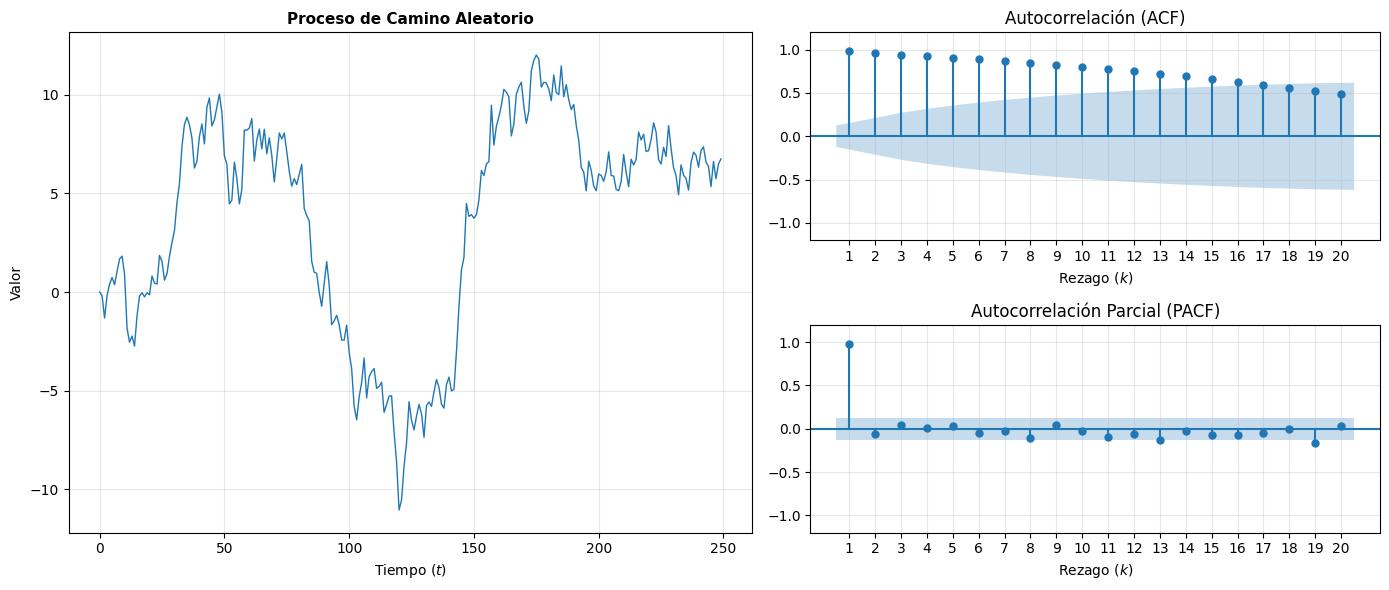

In [110]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_rw.index, serie_rw.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Proceso de Camino Aleatorio",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_rw, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_rw, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie del camino aleatorio es estacionaria. Usa un nivel de significancia de 5%.

In [111]:
resultado_adf_rw = adfuller(serie_rw)

print('Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio:')
print(f'Estadístico ADF: {resultado_adf_rw[0]:.4f}')
print(f'Valor p: {resultado_adf_rw[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_rw[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_rw[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio:
Estadístico ADF: -1.5093
Valor p: 0.5289
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/444268899.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_rw = adfuller(serie_rw)


(d) Aplica primeras diferencias al camino aleatorio. Grafica la serie resultante, su ACF y PACF, y testea su estacionariedad con un nivel de significancia de 5%.

/tmp/ipykernel_1521/676249039.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_rw_diff = adfuller(serie_rw_diff)



Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio (diferenciado):
Estadístico ADF: -14.8367
Valor p: 0.0000
Valores críticos:
   1%: -3.4570
   5%: -2.8733
   10%: -2.5730
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


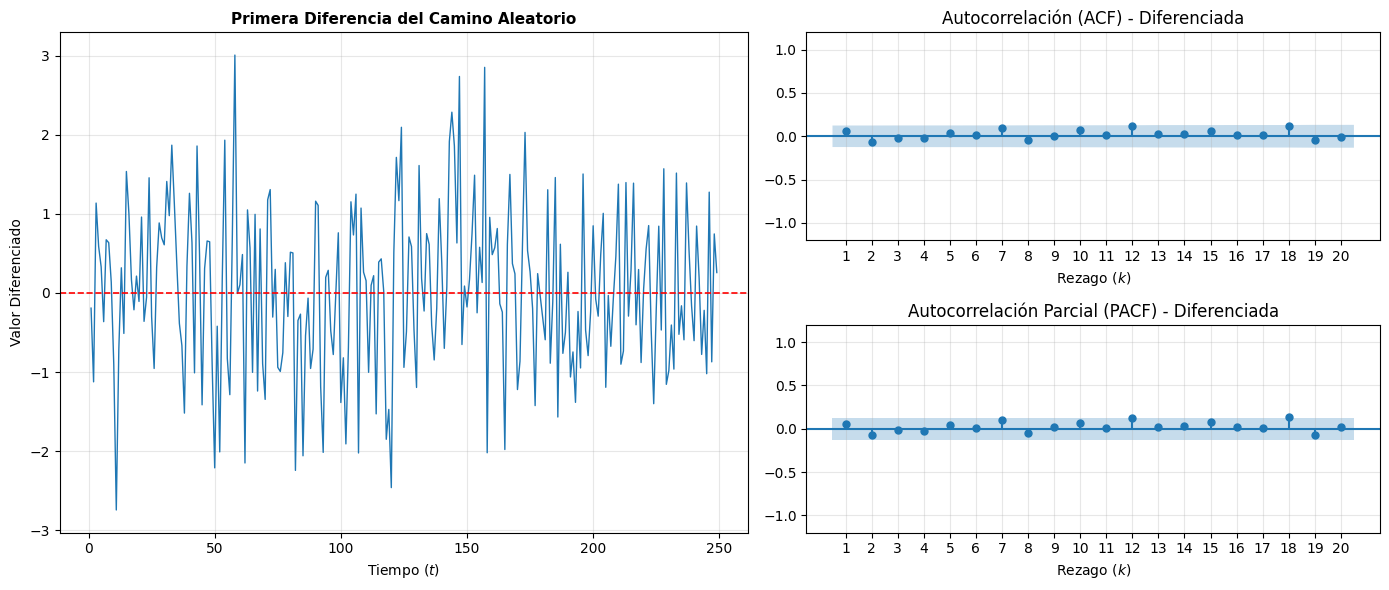

In [112]:
# 1. Aplicar la primera diferencia
serie_rw_diff = serie_rw.diff().dropna()

# 2. Realizar el test ADF a la serie diferenciada
resultado_adf_rw_diff = adfuller(serie_rw_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio (diferenciado):')
print(f'Estadístico ADF: {resultado_adf_rw_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_rw_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_rw_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_rw_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Opcional: Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_rw_diff.index, serie_rw_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera Diferencia del Camino Aleatorio", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor Diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_rw_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Serie diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_rw_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Serie diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Pregunta 6**

(a) Simula un proceso ARIMA(2,1,0).

Un proceso ARIMA(p,d,q) significa que la serie diferenciada 'd' veces es un proceso ARMA(p,q).

$$Y_t = 1.7 Y_{t-1} - 0.5 Y_{t-2} - 0.2 Y_{t-3} + \epsilon_t$$

donde $\epsilon_t \sim N(0,1)$.

En este caso, un ARIMA(2,1,0) implica que la **primera diferencia** de la serie es un proceso AR(2).



In [131]:
n_obs = 500
# np.random.seed(289) # Para reproducibilidad
epsilon_arima = np.random.normal(loc=0, scale=1, size=n_obs)

# Simulación directa del proceso ARIMA(2,1,0) no estacionario:
y_arima = np.zeros(n_obs)

# Condiciones iniciales (asumiendo Y_{-1}=Y_{-2}=Y_{-3}=0 para simplificar)
y_arima[0] = epsilon_arima[0]

if n_obs > 1:
    y_arima[1] = 1.7 * y_arima[0] + epsilon_arima[1]

if n_obs > 2:
    y_arima[2] = 1.7 * y_arima[1] - 0.5 * y_arima[0] + epsilon_arima[2]

# Para t >= 3
for t in range(3, n_obs):
    y_arima[t] = 1.7 * y_arima[t-1] + \
                 -0.5 * y_arima[t-2] - \
                 0.2 * y_arima[t-3] + epsilon_arima[t]

# Crear Serie con índice numérico secuencial
serie_arima = pd.Series(y_arima, name="ARIMA_210")

(b) Grafica la serie ARIMA(2,1,0), su función de autocorrelación (ACF) y autocorrelación parcial (PACF).

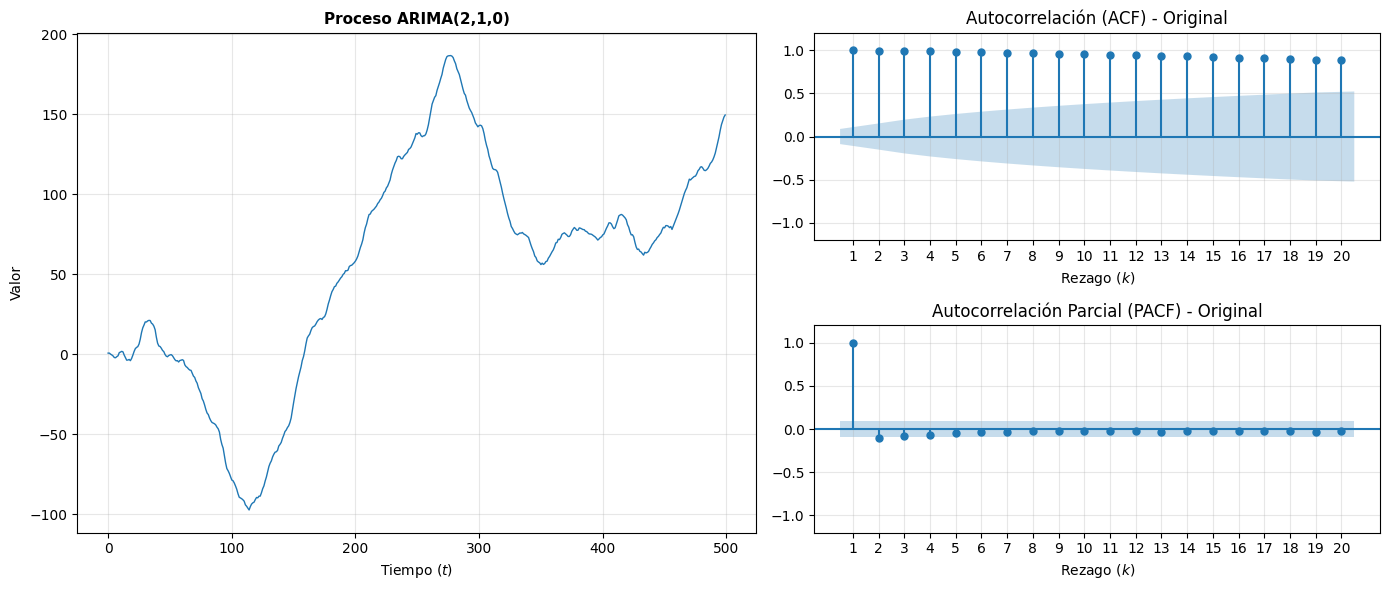

In [132]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_arima.index, serie_arima.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Proceso ARIMA(2,1,0)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_arima, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Original")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_arima, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Original", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie ARIMA(2,1,0) original es estacionaria. Usa un nivel de significancia de 5%.

In [133]:
resultado_adf_arima = adfuller(serie_arima)

print('Resultados del Test Dickey-Fuller Aumentado para la serie ARIMA(2,1,0) original:')
print(f'Estadístico ADF: {resultado_adf_arima[0]:.4f}')
print(f'Valor p: {resultado_adf_arima[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_arima[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_arima[1] <= 0.05:
    print('La serie original es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie original no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie ARIMA(2,1,0) original:
Estadístico ADF: -0.9588
Valor p: 0.7680
Valores críticos:
   1%: -3.4436
   5%: -2.8674
   10%: -2.5699
La serie original no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


/tmp/ipykernel_1521/2526440056.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_arima = adfuller(serie_arima)


(d) Aplica la primera diferencia a la serie ARIMA(2,1,0). Grafica la serie resultante, su ACF y PACF, y testea su estacionariedad con un nivel de significancia de 5%.

/tmp/ipykernel_1521/4137259805.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_arima_diff = adfuller(serie_arima_diff)



Resultados del Test Dickey-Fuller Aumentado para la serie ARIMA(2,1,0) (diferenciada):
Estadístico ADF: -5.0993
Valor p: 0.0000
Valores críticos:
   1%: -3.4436
   5%: -2.8674
   10%: -2.5699
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


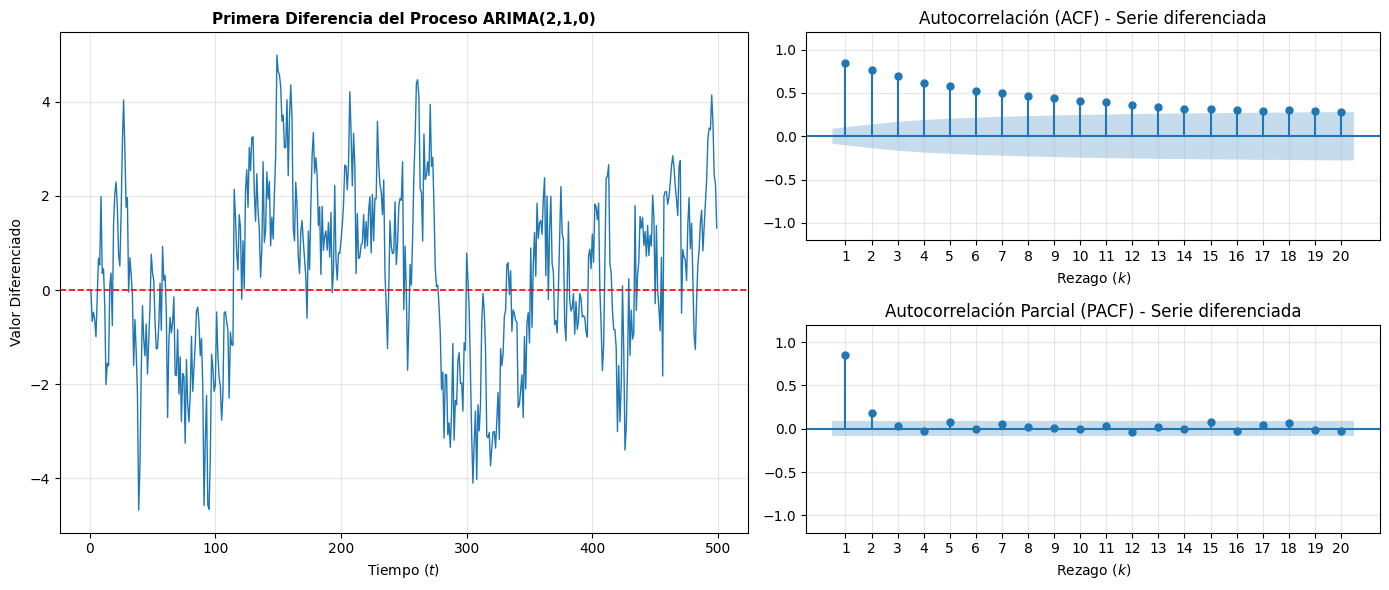

In [134]:
# 1. Aplicar la primera diferencia
serie_arima_diff = serie_arima.diff().dropna()

# 2. Realizar el test ADF a la serie diferenciada
resultado_adf_arima_diff = adfuller(serie_arima_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para la serie ARIMA(2,1,0) (diferenciada):')
print(f'Estadístico ADF: {resultado_adf_arima_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_arima_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_arima_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_arima_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_arima_diff.index, serie_arima_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera Diferencia del Proceso ARIMA(2,1,0)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor Diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_arima_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Serie diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_arima_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Serie diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(e) Aplica la función `auto_arima` de la librería `pmdarima` sobre la serie original ¿Qué obtienes?

In [138]:
import pmdarima as pm

In [141]:
model_auto_arima = pm.auto_arima(serie_arima,
                                 start_p=2, max_p=2,  # Forzar p=2
                                 # d=1,             # Forzar d=1
                                 start_q=0, max_q=0,  # Forzar q=0
                                 trace=True,
                                 suppress_warnings=True,
                                 seasonal=False,  # No estacional
                                 stepwise=True)

print(model_auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1407.206, Time=1.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2051.541, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1421.456, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2061.905, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1406.008, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1420.557, Time=0.19 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0]          
Total fit time: 2.033 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:               SARIMAX(2, 1, 0)   Log Likelihood                -700.004
Date:                Thu, 24 Sep 2026   AIC                           1406.008
Time:                        18:26:49   BIC                           1418.646
Sample:                             0   HQIC                          1410.968
          